# Run EzTaoX on DP1 DIA forced source catalog

This notebook demonstrates how to load DP1 data using LSDB and run EzTaoX fitting on DP1 light curves. 

In [1]:
from upath import UPath

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import arviz as az

import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax
import nested_pandas as npd
from numpyro.infer import MCMC, NUTS, init_to_median
from numpyro.handlers import seed as numpyro_seed

import lsdb
from eztaox.kernels.quasisep import Exp, MultibandLowRank
from eztaox.models import MultiVarModel
from eztaox.fitter import random_search

### Load data using LSDB

We are loading the DIA object catalog and using the forced photometry.

In [2]:
base_path = UPath("/rubin/lsdb_data")

dia_object_cat = lsdb.open_catalog(base_path / "dia_object_collection")
print('number of DIA objects in DP1:',len(dia_object_cat))

number of DIA objects in DP1: 1089818


In [3]:
dia_object_cat.head(5)

dec         diaObjectId  nDiaSources         ra  \
_healpix_29                                                              
9194470118511701   5.96977  648369431235264515            1   38.11965   
9194470480217677   5.97114  648369431235264518            1   38.11887   
9194500429915340  5.979788  648369431235264514            1  38.120496   
9194506361452432  5.981479  648369431235264517            1  38.108313   
9194527184923259   5.99389  648369431235264516            2  38.117915   

                   radecMjdTai  tract  \
_healpix_29                             
9194470118511701  60641.062221  10464   
9194470480217677  60641.062221  10464   
9194500429915340  60641.062221  10464   
9194506361452432  60641.062221  10464   
9194527184923259  60642.055203  10464   

                                              diaObjectForcedSource  \
_healpix_29                                                           
9194470118511701  [{band: 'g', coord_dec: 5.96977, coord_ra: 38....   
9194470480217677  [{band: 'g', coord_dec: 5.97114, coord_ra: 38....   
9194500429915340  [{band: 'g', coord_dec: 5.979788, coord_ra: 38...   
9194506361452432  [{band: 'g', coord_dec: 5.981479, coord_ra: 38...   
9194527184923259  [{band: 'g', coord_dec: 5.99389, coord_ra: 38....   

                                                          diaSource  
_healpix_29                                                          
9194470118511701  [{band: 'g', centroid_flag: False, coord_dec: ...  
9194470480217677  [{band: 'g', centroid_flag: False, coord_dec: ...  
9194500429915340  [{band: 'g', centroid_flag: False, coord_dec: ...  
9194506361452432  [{band: 'g', centroid_flag: False, coord_dec: ...  
9194527184923259  [{band: 'g', centroid_flag: False, coord_dec: ...

In [4]:
## get long light curves for testing
oc_long_lcs = dia_object_cat.query("nDiaSources > 500")
df_long_lcs = oc_long_lcs.head(5)

In [5]:
df_long_lcs

dec         diaObjectId  nDiaSources         ra  \
_healpix_29                                                                  
2528665081895373202 -28.344551  609788873886662663          512  53.122135   
2528689212471481767 -28.283192  609789629800906756          581  53.041797   
2528689652733440700 -28.243268  611253766972244112          567  53.033514   
2528691786073128755 -28.193302  611253766972243969          548  52.898762   
2528711291375799141 -28.312488  609789492361953287          513  53.321787   

                      radecMjdTai  tract  \
_healpix_29                                
2528665081895373202  60655.249976   4849   
2528689212471481767  60655.249976   4849   
2528689652733440700  60655.249193   5063   
2528691786073128755  60655.246436   5063   
2528711291375799141  60655.249976   4849   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
2528665081895373202  [{band: 'r', coord_dec: -28.344551, coord_ra: ...   
2528689212471481767  [{band: 'i', coord_dec: -28.283192, coord_ra: ...   
2528689652733440700  [{band: 'i', coord_dec: -28.243268, coord_ra: ...   
2528691786073128755  [{band: 'i', coord_dec: -28.193302, coord_ra: ...   
2528711291375799141  [{band: 'i', coord_dec: -28.312488, coord_ra: ...   

                                                             diaSource  
_healpix_29                                                             
2528665081895373202  [{band: 'r', centroid_flag: False, coord_dec: ...  
2528689212471481767  [{band: 'i', centroid_flag: False, coord_dec: ...  
2528689652733440700  [{band: 'i', centroid_flag: False, coord_dec: ...  
2528691786073128755  [{band: 'i', centroid_flag: False, coord_dec: ...  
2528711291375799141  [{band: 'i', centroid_flag: False, coord_dec: ...

In [6]:
df_long_lcs.iloc[0]['diaObjectForcedSource']

,band,coord_dec,coord_ra,diff_PixelFlags_nodataCenter,forcedSourceOnDiaObjectId,invalidPsfFlag,midpointMjdTai,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,...,pixelFlags_suspectCenter,psfDiffFlux,psfDiffFlux_flag,psfDiffFluxErr,psfFlux,psfFlux_flag,psfFluxErr,psfMag,psfMagErr,visit
0,r,-28.344551,53.122135,False,600320187779514373,False,60623.259895,False,False,False,...,False,-6062.086426,False,853.918945,736179.00000,False,855.450867,16.732542,0.001262,2024110800247
1,i,-28.344551,53.122135,False,600320187913732101,False,60623.260739,False,False,False,...,False,-8306.197266,False,1034.153809,849804.81250,False,1026.227539,16.576702,0.001311,2024110800248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,g,-28.344551,53.122135,False,600460950232367110,False,60655.249581,False,False,False,...,False,-234.308136,False,1201.546387,495222.34375,False,1202.385376,17.163000,0.002636,2024121000433
674,g,-28.344551,53.122135,False,600460950366584838,False,60655.249976,False,False,False,...,False,-5882.907227,False,1079.130127,489706.96875,False,1081.145264,17.175159,0.002397,2024121000434


In [7]:
## remove anything with a flag 

flag_cols = df_long_lcs.iloc[0]['diaObjectForcedSource'].columns[df_long_lcs.iloc[0]['diaObjectForcedSource'].columns.str.contains('flag', case=False)]
#print(flag_cols)
df_clean = df_long_lcs.iloc[0]['diaObjectForcedSource'].loc[~df_long_lcs.iloc[0]['diaObjectForcedSource'][flag_cols].any(axis=1)]
df_clean

,band,coord_dec,coord_ra,diff_PixelFlags_nodataCenter,forcedSourceOnDiaObjectId,invalidPsfFlag,midpointMjdTai,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,...,pixelFlags_suspectCenter,psfDiffFlux,psfDiffFlux_flag,psfDiffFluxErr,psfFlux,psfFlux_flag,psfFluxErr,psfMag,psfMagErr,visit
0,r,-28.344551,53.122135,False,600320187779514373,False,60623.259895,False,False,False,...,False,-6062.086426,False,853.918945,736179.00000,False,855.450867,16.732542,0.001262,2024110800247
1,i,-28.344551,53.122135,False,600320187913732101,False,60623.260739,False,False,False,...,False,-8306.197266,False,1034.153809,849804.81250,False,1026.227539,16.576702,0.001311,2024110800248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,g,-28.344551,53.122135,False,600460950232367110,False,60655.249581,False,False,False,...,False,-234.308136,False,1201.546387,495222.34375,False,1202.385376,17.163000,0.002636,2024121000433
674,g,-28.344551,53.122135,False,600460950366584838,False,60655.249976,False,False,False,...,False,-5882.907227,False,1079.130127,489706.96875,False,1081.145264,17.175159,0.002397,2024121000434


### Plot a few raw light curves for visualization

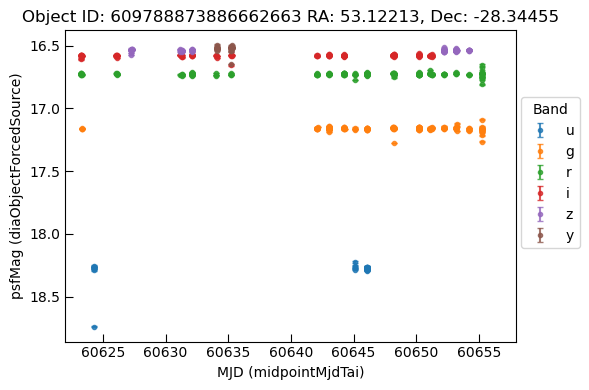

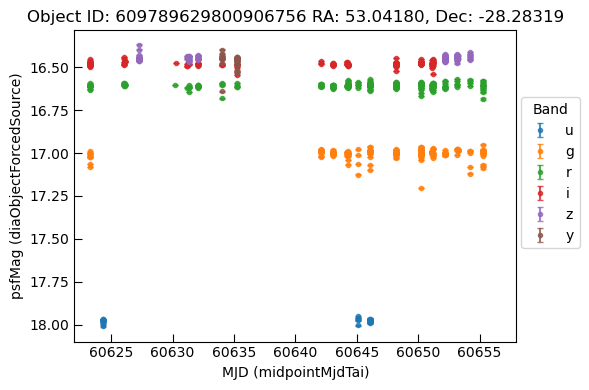

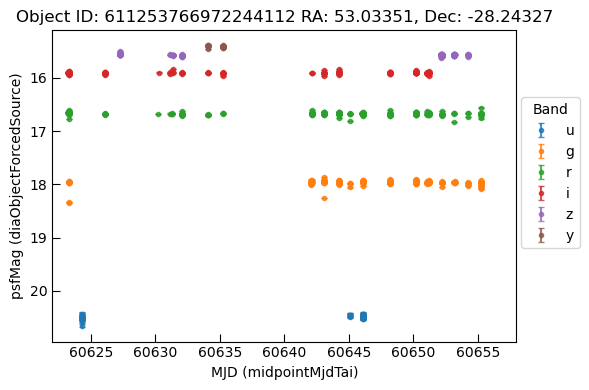

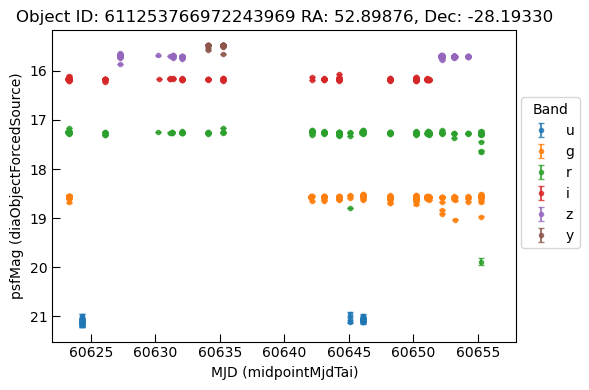

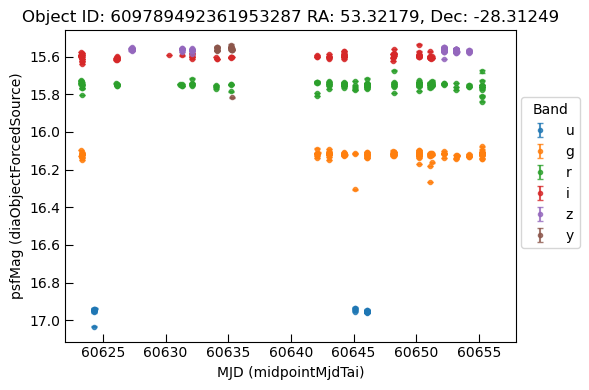

In [8]:
for i in range(len(df_long_lcs)):
    first_lc = df_long_lcs.iloc[i]['diaObjectForcedSource']

    ## remove any flags
    flag_cols = first_lc.columns[first_lc.columns.str.contains('flag', case=False)]
    first_lc = first_lc.loc[~first_lc[flag_cols].any(axis=1)] 
    
    # Start plot
    fig, ax = plt.subplots(figsize=(6,4))
    
    # Define band → color mapping
    band_colors = {"u": "blue", "g": "green", "r": "red", "i": "orange", "z": "purple", "y": "brown"}
    
    # Plot each band with its color
    for band, color in band_colors.items():
        band_data = first_lc[first_lc["band"] == band]
        if band_data.empty:
            continue
        ax.errorbar(
            band_data["midpointMjdTai"],
            band_data["psfMag"],
            yerr=band_data["psfMagErr"],
            fmt=".",
            #color=color,
            #ecolor=color,
            #elinewidth=2,
            capsize=2,
            alpha=0.8,
            #markeredgecolor="k",
            label=band,
        )
    
    plt.title(
        f'Object ID: {df_long_lcs.iloc[i]["diaObjectId"]} RA: {df_long_lcs.iloc[i]["ra"]:.5f}, Dec: {df_long_lcs.iloc[i]["dec"]:.5f}'
    )

    ax.invert_yaxis()
    ax.set_xlabel("MJD (midpointMjdTai)")
    ax.set_ylabel("psfMag (diaObjectForcedSource)")
    ax.set_xlim(60622, 60658)
    ax.legend(title="Band", loc=(1.01,0.3))
    ax.tick_params(axis='both', which='major', direction='in', size=6)  
    plt.tight_layout()

### clean up light curves 

- remove 10-sigma outliers in each night
- bin the data into nightly epochs: take mean(mag) in each night
- adjust the magnitude uncertainties: add in quaduature mean(magerr) and std(mag) in each night

In [9]:
def combine_mag(mag, mag_err):

    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    
    ## add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err)**2+np.nanstd(mag)**2)
    
    return mag_w, mag_w_err

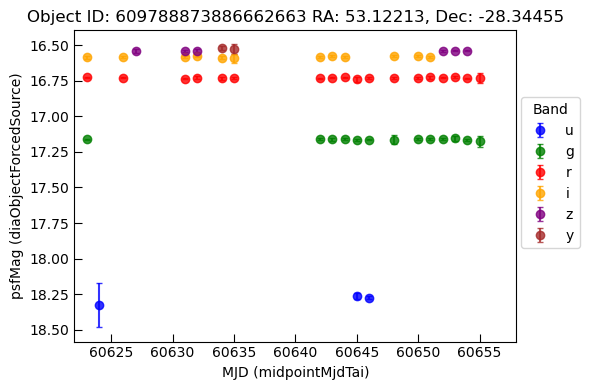

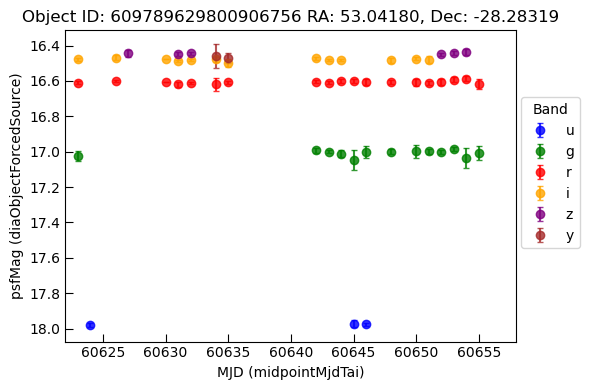

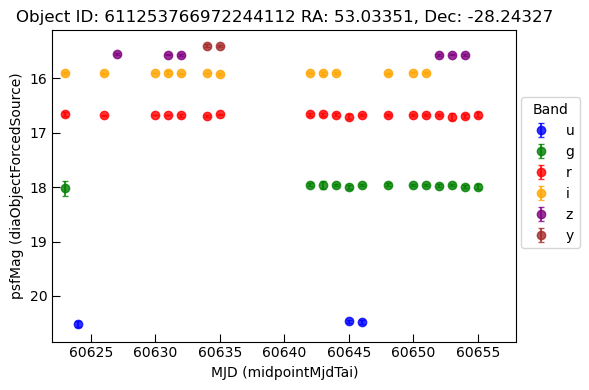

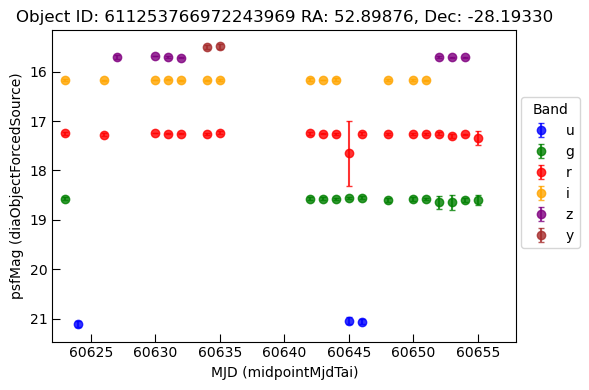

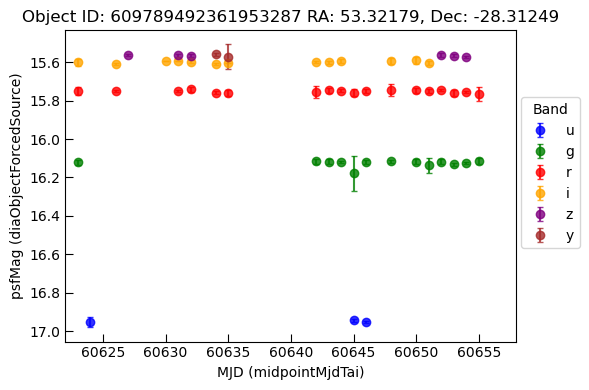

In [10]:
rebin = True
band_colors = {"u": "blue", "g": "green", "r": "red", "i": "orange", "z": "purple", "y": "brown"}

for i in range(len(df_long_lcs)):

    fig, ax = plt.subplots(figsize=(6,4))

    first_lc = df_long_lcs.iloc[i]['diaObjectForcedSource']
    first_lc = first_lc.dropna()
    
    ## remove any flags
    flag_cols = first_lc.columns[first_lc.columns.str.contains('flag', case=False)]
    first_lc = first_lc.loc[~first_lc[flag_cols].any(axis=1)] 
    
    times, mags, mag_errs = {}, {}, {}
    for ib, b in enumerate('ugrizy'):
        band_data = first_lc[first_lc["band"] == b]
        if band_data.empty:
            continue
            
        times_band = band_data["midpointMjdTai"]#-first_lc["midpointMjdTai"].min()
        mags_band = band_data["psfMag"]
        magerrs_band = band_data["psfMagErr"]

        ## remove 10 sigma outliers in each band
        sigma = np.abs(mags_band-np.mean(mags_band))/np.std(mags_band)
        #print(sigma.values)
        #print(np.percentile(sigma.values,[16,84])-np.percentile(sigma.values,[50,50]),np.max(sigma))
        mags_band = mags_band[sigma<10]
        magerrs_band = magerrs_band[sigma<10]
    
        if rebin == True:
            times[ib] = np.unique(np.round(times_band))
            mags[ib] = []
            mag_errs[ib] = []
            for it in times[ib]:
                mask = np.round(times_band) == it
                tmp_mag, tmp_err = combine_mag(mags_band[mask], magerrs_band[mask])
                mags[ib].append(tmp_mag)
                mag_errs[ib].append(tmp_err)
        else:
            times[ib] = times_band.values
            mags[ib] = mags_band.values
            mag_errs[ib] = magerrs_band.values 

        ax.errorbar(
            times[ib],
            mags[ib],
            yerr=mag_errs[ib],
            fmt="o",
            color=band_colors[b],
            #ecolor=color,
            #elinewidth=2,
            capsize=2,
            alpha=0.8,
            #markeredgecolor="k",
            label=b,
        )

    plt.title(
        f'Object ID: {df_long_lcs.iloc[i]["diaObjectId"]} RA: {df_long_lcs.iloc[i]["ra"]:.5f}, Dec: {df_long_lcs.iloc[i]["dec"]:.5f}'
    )

    ax.invert_yaxis()
    ax.set_xlabel("MJD (midpointMjdTai)")
    ax.set_ylabel("psfMag (diaObjectForcedSource)")
    ax.set_xlim(60622, 60658)
    ax.legend(title="Band", loc=(1.01,0.3))
    ax.tick_params(axis='both', which='major', direction='in', size=6)  
    plt.tight_layout()

### run EzTaoX fitting between r, i bands

Here, we run EzTaoX between r and i bands to extract the r-i lags, and plot the nightly-binned light curves and DRW fitting results. 

Since DP1 baseline is short ($\sim$30 days), it is unlikely to fit the DRW parameters accurately, so we fix the DRW parameters to (values, values) for now. We set the limits of the lags to be $\pm$10 days ($\sim$1/3 of the baseline). For longer baselines, simple MLE fitting results can be used as initial guess for the MCMC fitting. 


In [11]:
def clean_lightcurves(df):

    lc = df['diaObjectForcedSource']
    lc = lc.dropna()
    
    ## remove any flags
    flag_cols = lc.columns[lc.columns.str.contains('flag', case=False)]
    lc = lc.loc[~lc[flag_cols].any(axis=1)] 
    
    times, mags, mag_errs = {}, {}, {}
    for ib, b in enumerate('ugrizy'):
        band_data = lc[lc["band"] == b]
        if band_data.empty:
            continue
            
        times_band = band_data["midpointMjdTai"]#-lc["midpointMjdTai"].min()
        mags_band = band_data["psfMag"]
        magerrs_band = band_data["psfMagErr"]

        ## remove 10 sigma outliers in each band
        sigma = np.abs(mags_band-np.mean(mags_band))/np.std(mags_band)
        #print(sigma.values)
        #print(np.percentile(sigma.values,[16,84])-np.percentile(sigma.values,[50,50]),np.max(sigma))
        mags_band = mags_band[sigma<5]
        magerrs_band = magerrs_band[sigma<5]
        
        times[ib] = np.unique(np.round(times_band))
        mags[ib] = []
        mag_errs[ib] = []
        for i in times[ib]:
            mask = np.round(times_band) == i
            tmp_mag, tmp_err = combine_mag(mags_band[mask], magerrs_band[mask])
            mags[ib].append(tmp_mag)
            mag_errs[ib].append(tmp_err)

    return times, mags, mag_errs

In [12]:
def format_lightcurves(times, mags, magerrs, bands=None):

    inds = jnp.argsort(jnp.concatenate([times[b] for b in bands]))
        
    X = (
        jnp.concatenate([times[b] for b in bands])[inds],
        jnp.concatenate(
            [i * jnp.ones_like(times[b], dtype=int) for i, b in enumerate(bands)]
        )[inds],
    )

    mags_median = []
    for b in bands:
        mags[b] = jnp.array(mags[b])
        #print(np.median(mags[b]))
        mags_median.append(jnp.median(mags[b]))
        mags[b] -= jnp.median(mags[b])
    
    y = jnp.concatenate([jnp.array(mags[b]) for b in bands])[inds]
    yerr = jnp.concatenate([jnp.array(mag_errs[b]) for b in bands])[inds]
    
    return X, y, yerr, mags_median

In [13]:
def initSampler():
    
    # GP kernel param
    log_drw_scale = numpyro.sample(
        "drw_scale", dist.Uniform(jnp.log(0.01), jnp.log(1000))
    )
    log_drw_sigma = numpyro.sample(
        "drw_sigma", dist.Uniform(jnp.log(0.01), jnp.log(10))
    )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(0, 10))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }

    return sample_params    

In [14]:
def run_MLEfitting(X, y, yerr, sampler=initSampler, has_lag = True, zero_mean=True):

    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=2.0) ## random initial value
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)

    sample_key = jax.random.PRNGKey(1)
    prior_sample = numpyro_seed(sampler, rng_seed=sample_key)()
    model = m
    fit_key = jax.random.PRNGKey(1)
    nSample = 1_000
    nBest = 5  # it seems like this number needs to be high
    
    bestP, ll = random_search(model, sampler, fit_key, nSample, nBest)

    return bestP, ll;

In [15]:
def plot_MCMC(X, y, yerr, mcmc, outfile=None, trace_vars=None,  has_lag=True, zero_mean=True):

    # Draw one sample from MCMC and extract parameters
    mcmc_samples = mcmc.get_samples()
    sample_idx = 100 # Use first sample
    params_sample = {k: v[sample_idx] for k, v in mcmc_samples.items()}
    
    band_colors = {"u": "blue", "g": "green", "r": "red", "i": "orange", "z": "purple", "y": "brown"}
    
    # Create prediction grid (finer time resolution for smooth curves)
    pred_times = jnp.linspace(X[0].min(), X[0].max(), 200)
    pred_X = (pred_times, jnp.zeros_like(pred_times, dtype=int))  # Band 0
    
    # Make prediction for each band
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.75, 1], wspace=0.1)
    
    ax0 = fig.add_subplot(ax[0, 0])
    n_vars = len(trace_vars)
    ax_r = ax[0, 1].subgridspec(nrows=n_vars, ncols=2, hspace=0.4, wspace=0.25)
    ax1 = np.asarray(
        [[fig.add_subplot(ax_r[r, c]) for c in range(2)] for r in range(n_vars)],
        dtype=object,
    )

    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(params_sample)
    model = m
    
    for i, b in enumerate('ri'):
        # Create prediction for this band
        pred_X_band = (pred_times, jnp.full_like(pred_times, i, dtype=int))
        mu, std = model.pred(params_sample, pred_X_band)
        
        # Plot observed data
        mask = X[1] == i
        
        # Plot prediction
        ax0.plot(pred_times, mu, '-', linewidth=1, alpha=0.5, color=band_colors[b])
        ax0.fill_between(pred_times, mu - std , mu + std , alpha=0.2, color=band_colors[b])
        ax0.errorbar(X[0][mask], y[mask], yerr=yerr[mask], fmt='.', label=b,zorder=-100, color=band_colors[b])
    
        
        ax0.set_xlabel('Time (days)')
        ax0.set_ylabel('Scaled Magnitude')
        ax0.invert_yaxis()
        ax0.legend(loc='upper left')
    
    az.plot_trace(
        az.from_numpyro(mcmc),
        var_names=trace_vars,
        axes=ax1,   
    )
    
    plt.tight_layout()
    if outfile !=None:
        plt.savefig(outfile=outfile,bbox_inches='tight')
    else:
        plt.show()


In [16]:
def run_MCMC(X, y, yerr, sampler=initSampler, has_lag = True, zero_mean=True, fixed_params=None):
    
    nuts_kernel = NUTS(
        numpyro_model,
        dense_mass=True,
        target_accept_prob=0.9,
        init_strategy=init_to_median,
    )
    
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=500,
        num_samples=1000,
        num_chains=1,
        # progress_bar=False,
    )
    
    mcmc_seed = 0
    mcmc.run(jax.random.PRNGKey(mcmc_seed), X, yerr, y=y, has_lag=has_lag, zero_mean=zero_mean, fixed_params=fixed_params)
    data = az.from_numpyro(mcmc)
    mcmc.print_summary()

    return mcmc

In [17]:
def numpyro_model(X, yerr, y=None, has_lag=True, zero_mean=True, fixed_params = None):

    # GP kernel param
    if "log_drw_scale" in fixed_params:
        log_drw_scale = fixed_params['log_drw_scale']
    else:
        log_drw_scale =    numpyro.sample(
            "log_drw_scale", dist.Uniform(jnp.log(10), jnp.log(100))
        )
    if "log_drw_sigma" in fixed_params:
        log_drw_sigma = fixed_params['log_drw_sigma']
    else:
        log_drw_sigma = numpyro.sample(
            "log_drw_sigma", dist.Uniform(jnp.log(1e-2), jnp.log(10))
        )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(-10, 10))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }

    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(sample_params)

sample: 100%|██████████| 1500/1500 [00:05<00:00, 264.23it/s, 23 steps of size 4.85e-01. acc. prob=0.92]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
            lag      0.07      5.60      0.19     -8.55      8.91    987.93      1.00
  log_amp_scale     -1.05      0.64     -1.15     -1.99     -0.10   1096.11      1.00
  log_drw_sigma     -4.37      0.21     -4.43     -4.60     -4.06   1263.44      1.00
        mean[0]     -0.00      0.06      0.00     -0.10      0.08    741.80      1.00
        mean[1]     -0.00      0.06      0.00     -0.10      0.08   1214.27      1.00

Number of divergences: 0


/tmp/ipykernel_44425/80454845.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


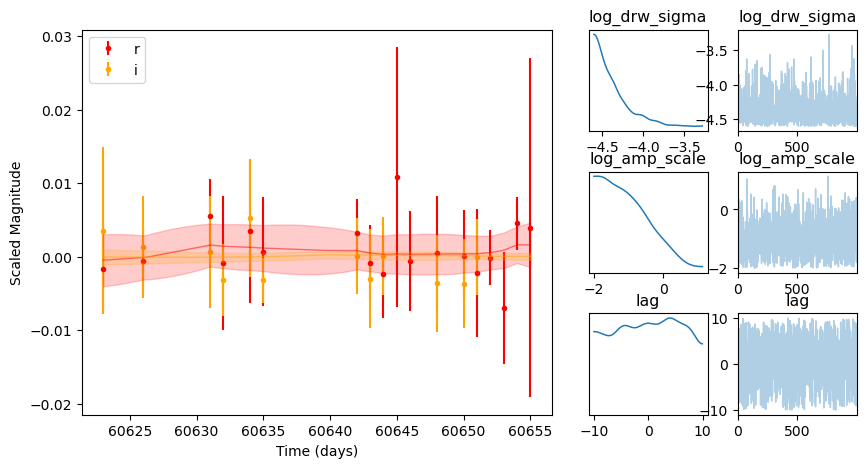

sample: 100%|██████████| 1500/1500 [00:05<00:00, 274.80it/s, 31 steps of size 2.26e-01. acc. prob=0.89]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
            lag      1.01      5.27      1.24     -6.76     10.00    597.81      1.00
  log_amp_scale     -0.83      0.64     -0.85     -1.96      0.08    769.94      1.00
  log_drw_sigma     -4.29      0.26     -4.36     -4.60     -3.93    924.15      1.00
        mean[0]      0.00      0.06      0.00     -0.09      0.09    623.69      1.00
        mean[1]      0.00      0.06      0.00     -0.08      0.10    815.55      1.00

Number of divergences: 0


/tmp/ipykernel_44425/80454845.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


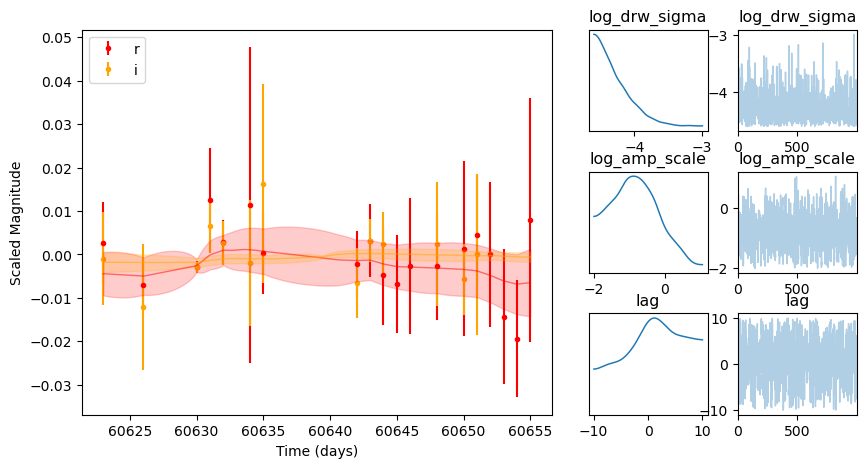

sample: 100%|██████████| 1500/1500 [00:05<00:00, 268.80it/s, 63 steps of size 7.35e-02. acc. prob=0.96]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
            lag      7.43      2.09      7.87      4.41      9.99    718.82      1.01
  log_amp_scale      0.20      0.53      0.20     -0.74      0.98    405.24      1.01
  log_drw_sigma     -4.19      0.34     -4.27     -4.60     -3.73    745.44      1.00
        mean[0]      0.00      0.06     -0.00     -0.08      0.10    538.27      1.00
        mean[1]     -0.00      0.06     -0.00     -0.10      0.07    335.67      1.00

Number of divergences: 1


/tmp/ipykernel_44425/80454845.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


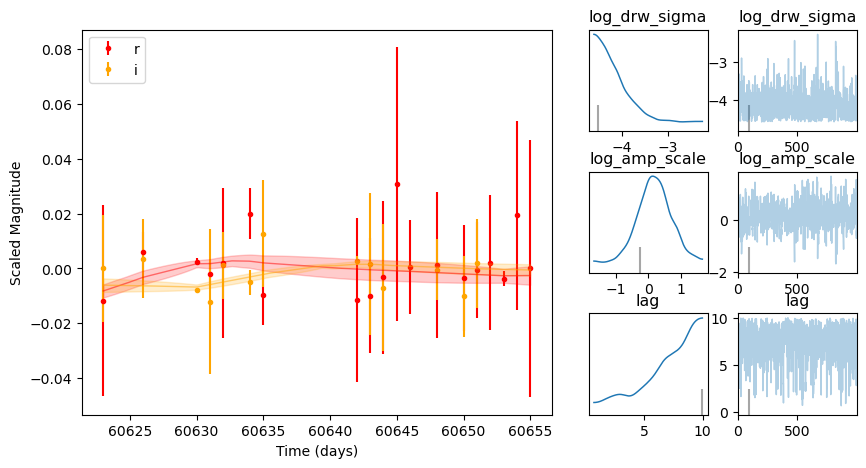

sample: 100%|██████████| 1500/1500 [00:05<00:00, 256.37it/s, 31 steps of size 8.20e-02. acc. prob=0.89] 



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
            lag     -0.17      4.99     -0.00     -7.97      8.73    279.79      1.00
  log_amp_scale     -0.57      0.39     -0.59     -1.15      0.13    384.82      1.01
  log_drw_sigma     -3.67      0.41     -3.69     -4.37     -3.07    502.67      1.00
        mean[0]     -0.00      0.06     -0.00     -0.08      0.10    501.68      1.00
        mean[1]      0.00      0.06      0.00     -0.10      0.08    504.81      1.00

Number of divergences: 0


/tmp/ipykernel_44425/80454845.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


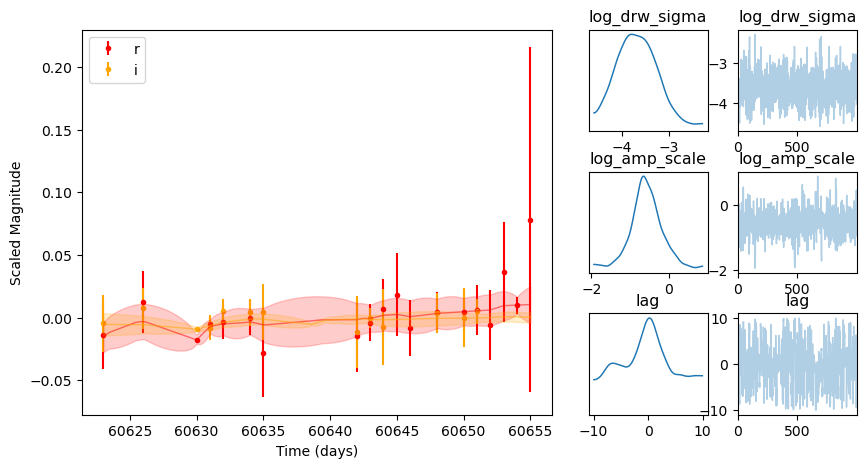

sample: 100%|██████████| 1500/1500 [00:05<00:00, 274.21it/s, 15 steps of size 2.48e-01. acc. prob=0.88]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
            lag      0.22      5.16      0.65     -9.83      7.19    400.21      1.00
  log_amp_scale      0.45      0.46      0.47     -0.29      1.18    430.04      1.00
  log_drw_sigma     -4.20      0.34     -4.26     -4.60     -3.73    442.72      1.00
        mean[0]     -0.00      0.06     -0.01     -0.10      0.08    710.86      1.00
        mean[1]     -0.00      0.06     -0.00     -0.09      0.08    860.95      1.00

Number of divergences: 0


/tmp/ipykernel_44425/80454845.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


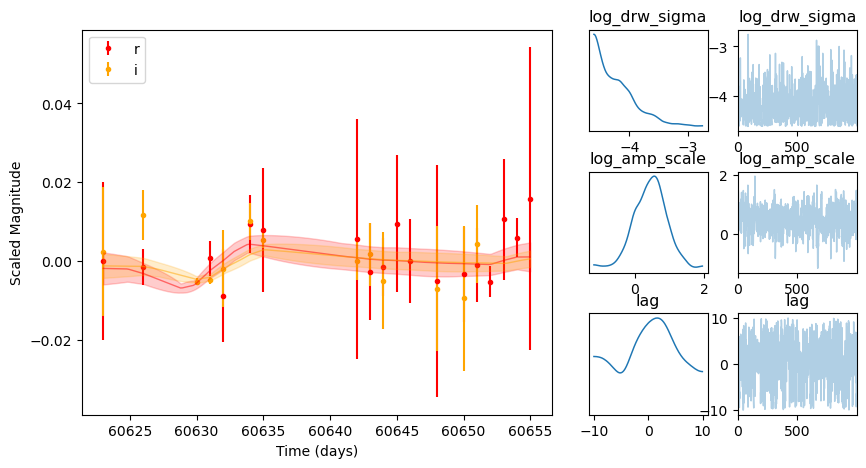

In [18]:
for i in range(len(df_long_lcs)):

    ## light curve cleaning
    times, mags, mag_errs = clean_lightcurves(df_long_lcs.iloc[i])
    
    ## run MLE, use results for MCMC fitting
    X, y, yerr, mags_median = format_lightcurves(times, mags, mag_errs, bands=[2,3])
    bestP, ll = run_MLEfitting(X, y, yerr, sampler=initSampler, has_lag = True, zero_mean=True)
    
    ## run MCMC fitting
    fixed_params = {"log_drw_scale": jnp.log(100.),
                    #"log_drw_sigma": jnp.log(0.0067)
                   }
    mcmc = run_MCMC(X, y, yerr, sampler=initSampler, has_lag = True, zero_mean=True, fixed_params=fixed_params)

    ## plot results
    trace_vars = ["log_drw_scale", "log_drw_sigma", "log_amp_scale", "lag"]
    trace_vars = [v for v in trace_vars if fixed_params.get(v) is None]
    
    plot_MCMC(X, y, yerr, mcmc, trace_vars=trace_vars,)

In [19]:
bands = [2,3]
inds = jnp.argsort(jnp.concatenate([times[b] for b in bands]))
X = (
    jnp.concatenate([times[b] for b in bands])[inds],
    jnp.concatenate(
        [i * jnp.ones_like(times[b], dtype=int) for i, b in enumerate(bands)]
    )[inds],
)

mags_median = []
for b in bands:
    mags[b] = jnp.array(mags[b])
    print(np.median(mags[b]))
    mags_median.append(jnp.median(mags[b]))
    mags[b] -= jnp.median(mags[b])

y = jnp.concatenate([jnp.array(mags[b]) for b in bands])[inds]
yerr = jnp.concatenate([jnp.array(mag_errs[b]) for b in bands])[inds]

print(mags_median)

0.0
0.0
[Array(0., dtype=float32), Array(0., dtype=float32)]


In [20]:
has_lag = True  # if fit interband lags
zero_mean = True  # if fit a mean function
nBand = len(bands)
k = Exp(scale=100.0, sigma=2.0)
m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)

In [21]:
def initSampler():
    # GP kernel param
    log_drw_scale = numpyro.sample(
        "drw_scale", dist.Uniform(jnp.log(0.01), jnp.log(1000))
    )
    log_drw_sigma = numpyro.sample(
        "drw_sigma", dist.Uniform(jnp.log(0.01), jnp.log(10))
    )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(0, 20))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }

    return sample_params

In [22]:
sample_key = jax.random.PRNGKey(1)
prior_sample = numpyro_seed(initSampler, rng_seed=sample_key)()
model = m
sampler = initSampler
fit_key = jax.random.PRNGKey(1)
nSample = 1_000
nBest = 5  # it seems like this number needs to be high

bestP, ll = random_search(model, initSampler, fit_key, nSample, nBest)


In [23]:
bestP

{'lag': Array(0.99999695, dtype=float64),
 'log_amp_scale': Array(1.33466698, dtype=float64),
 'log_kernel_param': Array([ 0.47524958, -6.79653562], dtype=float64),
 'mean': Array([ 0.08512585, -0.0168791 ], dtype=float64)}

## run parallel